# Revision: Thermodynamic Filter Bias and Extended BEP Analysis

Objective: evaluate whether the `DeltaG_rxn < -4.1 kcal/mol` thermodynamic filter artificially induces the BEP relationship, and quantify how the thermodynamically filtered-out TS/IRC results affect the BEP interpretation.

Primary reviewer-runnable inputs:
- `Data/TS/result_filter_extended.csv` and `Data/TS/result_filter_extended.xyz`: the already prepared thermodynamic-filter-failed TS set.
- Entries with `N_Index == 5` are excluded at the top of the notebook because Nu5 undergoes SF3 radical detachment rather than the target XAT transition state.
- `Data/TS/Borane_all.csv`: final curated reaction dataset used for the qharm rerun below.


## Plan

1. Load the local filter-failed table from `Data/TS` and exclude `N_Index == 5` immediately.
2. Confirm that the matching extended XYZ file is present and has the expected number of structures.
3. Merge component metadata so the extended table can use the same descriptor/coverage bookkeeping as the final set.
4. Refit BEP relationships for the final-only, filter-failed-only, and combined datasets.
5. Restrict the extended-fit line to `deltaG_qharm(kcal/mol) > -4.1 kcal/mol` so the thermodynamically unfavorable region is fitted explicitly.
6. Compare a reproducible random 900-point sample from the 8980-row final set with the 946 filter-failed rows to show BEP correlation at a similar sample size.
7. Check descriptor coverage for all retained filter-failed rows.


In [3]:
from __future__ import annotations

from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from DFTStructureGenerator.thermochemistry import database_path, load_reaction_dataset

RANDOM_STATE = 0
THERMO_CUTOFF = -4.1
SAMPLED_FINAL_N = 900

DATA_TS_DIR = Path("Data/TS")
CSV_DIR = Path("Data/csvs")
DESCRIPTOR_DIR = Path("Data/descriptor")
FIGURE_DIR = Path("Figure")
IGNORED_DIR = Path("Ignored")
OUTPUT_DIR = IGNORED_DIR / "revision_thermo_filter_outputs"

EXTENDED_SOURCE_CSV = DATA_TS_DIR / "result_filter_extended_raw_including_Nu5.csv"
EXTENDED_CSV = DATA_TS_DIR / "result_filter_extended.csv"
EXTENDED_XYZ = DATA_TS_DIR / "result_filter_extended.xyz"
EXTENDED_XYZ_SUMMARY = DATA_TS_DIR / "result_filter_extended_xyz_summary.csv"
FINAL_CSV = DATA_TS_DIR / "Borane_all.csv"
# Thermochemistry switch for both the final and extended reaction sets.
USE_QHARM = True
DB_PATH = database_path(USE_QHARM)
FINAL_BARRIER_COLUMN = "deltaGa_qharm(kcal/mol)" if USE_QHARM else "deltaGa(kcal/mol)"
FINAL_REACTION_ENERGY_COLUMN = "deltaG_qharm(kcal/mol)" if USE_QHARM else "deltaG(kcal/mol)"
EXTENDED_BARRIER_COLUMN = "deltaGa_qharm(kcal/mol)" if USE_QHARM else "deltaGa(kcal/mol)"
EXTENDED_REACTION_ENERGY_COLUMN = "deltaG_qharm(kcal/mol)" if USE_QHARM else "deltaG(kcal/mol)"
BN_COMPLEXATION_COLUMN = "deltaG_comb_qharm(kcal/mol)" if USE_QHARM else "deltaG_comb(kcal)"

# Exclude Nu5 from the extended set: it follows SF3 radical detachment rather than target XAT.
EXCLUDED_N_INDEXES = [5]

FIGURE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_TS_DIR.mkdir(exist_ok=True)


## 1. Load Local Extended Set And Exclude Nu5

For reviewer-style reruns, start from the prepared files in `Data/TS`: `result_filter_extended.csv` and `result_filter_extended.xyz`. The raw E-drive Gaussian workspace was used only once to prepare these local artifacts and is not required for the BEP analyses below.

If a raw local copy including Nu5 is intentionally placed at `Data/TS/result_filter_extended_raw_including_Nu5.csv`, the next cell will use it and remove `N_Index == 5`; otherwise it uses the already-filtered `Data/TS/result_filter_extended.csv`.


In [7]:
source_csv = EXTENDED_SOURCE_CSV if EXTENDED_SOURCE_CSV.exists() else EXTENDED_CSV
assert source_csv.exists(), source_csv

extended_source = pd.read_csv(source_csv)
for col in ["B_Index", "N_Index", "Cl_Index"]:
    extended_source[col] = extended_source[col].astype(int)

excluded_by_nu = extended_source.loc[extended_source["N_Index"].isin(EXCLUDED_N_INDEXES)].copy()
extended_raw = extended_source.loc[~extended_source["N_Index"].isin(EXCLUDED_N_INDEXES)].copy()

print(f"Source CSV: {source_csv}")
print(f"Raw/source rows: {len(extended_source)}")
print(f"Excluded rows with N_Index in {EXCLUDED_N_INDEXES}: {len(excluded_by_nu)}")
print(f"Analysis extended rows: {len(extended_raw)}")

extended_raw.shape, extended_raw.head()


Source CSV: Data\TS\result_filter_extended.csv
Raw/source rows: 890
Excluded rows with N_Index in [5]: 0
Analysis extended rows: 890


((890, 14),
    B_Index  N_Index  Cl_Index  conf_idxs_ts         TS_G  deltaG(kcal/mol)  \
 0      388       71       492            10 -2436.856731         20.231855   
 1      388      143       480             2 -1979.710016         20.036138   
 2      388      143       483             0 -1924.334580          2.549219   
 3      388      143       485             0 -1946.302429         -3.588484   
 4      388      143       492            11 -1794.912201         25.223994   
 
    deltaGa(kcal/mol)      B_Cl      C_Cl  G_energy_qharm   TS_G_qharm  \
 0          25.834702  2.252840  1.989601    -2437.072759 -2437.037561   
 1          26.048686  2.229465  2.020106    -1979.829595 -1979.792276   
 2          29.818869  2.161498  2.034505    -1924.459441 -1924.414890   
 3          46.673224  2.231557  2.040379    -1946.474187 -1946.435682   
 4          30.928239  2.016620  2.036674    -1795.034761 -1794.989662   
 
    deltaG_react_qharm  deltaG_qharm(kcal/mol)  deltaGa_qharm(kcal

### Optional Provenance: Generate Local Extended CSV/XYZ From The Historical E-Drive Workspace

`[RAW-GAUSSIAN/E:/work]` This cell records the one-time preparation step used to create the local `Data/TS/result_filter_extended.csv` and `Data/TS/result_filter_extended.xyz` files from the historical raw Gaussian workspace. It is disabled by default and should be skipped by reviewers, because the manuscript/revision analyses below only need the prepared `Data/TS` files. The E-drive source has already been processed in our working copy; rerunning this cell is only for internal provenance if the raw workspace is restored.


In [8]:
# [RAW-GAUSSIAN/E:/work] Optional one-time provenance/export cell.
# Reviewers should skip this cell: the BEP analysis starts from Data/TS/result_filter_extended.csv
# and Data/TS/result_filter_extended.xyz, which were already prepared from the raw calculation workspace.

RUN_RAW_E_DRIVE_XYZ_EXPORT = False

if RUN_RAW_E_DRIVE_XYZ_EXPORT:
    from DFTStructureGenerator.logfile_process import Logfile

    RAW_EXTENDED_CSV = Path(r"E:/work/B_Cl_Nu/Sum/result_filter_extended.csv")
    RAW_TS_DIR = Path(r"E:/work/B_Cl_Nu/Sum/TS_needIRC")

    assert RAW_EXTENDED_CSV.exists(), RAW_EXTENDED_CSV
    assert RAW_TS_DIR.exists(), RAW_TS_DIR

    raw_e_df = pd.read_csv(RAW_EXTENDED_CSV)
    for col in ["B_Index", "N_Index", "Cl_Index", "Conf_id"]:
        raw_e_df[col] = raw_e_df[col].astype(int)

    retained_e_df = raw_e_df.loc[~raw_e_df["N_Index"].isin(EXCLUDED_N_INDEXES)].copy()
    retained_e_df.to_csv(EXTENDED_CSV, index=False)

    def candidate_ts_logs(row):
        b = int(row["B_Index"])
        n = int(row["N_Index"])
        cl = int(row["Cl_Index"])
        conf = int(row["Conf_id"])
        exact_names = [
            RAW_TS_DIR / f"B_{b:05}_Nu_{n:05}_Cl_{cl:05}_{conf:04}.log",
            RAW_TS_DIR / f"B_{b:05}_Nu_{n:05}_Cl_{cl:05}.log",
        ]
        globbed = sorted(RAW_TS_DIR.glob(f"B_{b:05}_Nu_{n:05}_Cl_{cl:05}*.log"))
        seen = set()
        for path in exact_names + globbed:
            if path not in seen:
                seen.add(path)
                yield path

    def read_ts_xyz(row):
        tried = []
        for log_path in candidate_ts_logs(row):
            tried.append(str(log_path))
            if not log_path.exists():
                continue
            log = Logfile(str(log_path), ignore_print=True)
            if log.running_positions is None or len(log.running_positions) == 0:
                continue
            return log_path, log.symbol_list, log.running_positions[-1]
        raise FileNotFoundError("No readable TS log found. Tried: " + "; ".join(tried))

    xyz_records = []
    with EXTENDED_XYZ.open("w", encoding="utf-8") as handle:
        for _, row in retained_e_df.iterrows():
            log_path, symbols, positions = read_ts_xyz(row)
            comment = (
                f"B_Index={int(row['B_Index'])}; "
                f"N_Index={int(row['N_Index'])}; "
                f"Cl_Index={int(row['Cl_Index'])}; "
                f"Conf_id={int(row['Conf_id'])}; "
                f"source={log_path.as_posix()}"
            )
            handle.write(f"{len(symbols)}\n{comment}\n")
            for symbol, xyz in zip(symbols, positions):
                x, y, z = map(float, xyz)
                handle.write(f"{symbol:<2} {x:16.8f} {y:16.8f} {z:16.8f}\n")
            xyz_records.append({
                "B_Index": int(row["B_Index"]),
                "N_Index": int(row["N_Index"]),
                "Cl_Index": int(row["Cl_Index"]),
                "Conf_id": int(row["Conf_id"]),
                "natoms": len(symbols),
                "source_log": log_path.as_posix(),
            })

    xyz_generation_summary = pd.DataFrame(xyz_records)
    print(f"Raw E-drive rows: {len(raw_e_df)}")
    print(f"Excluded Nu rows: {len(raw_e_df) - len(retained_e_df)}")
    print(f"Wrote local CSV: {EXTENDED_CSV} ({len(retained_e_df)} rows)")
    print(f"Wrote local XYZ: {EXTENDED_XYZ} ({len(xyz_generation_summary)} structures)")
    display(xyz_generation_summary.head())
else:
    print("Skipped raw E-drive export. Use the prepared Data/TS/result_filter_extended.csv and .xyz files for reviewer-runnable analysis.")


Skipped raw E-drive export. Use the prepared Data/TS/result_filter_extended.csv and .xyz files for reviewer-runnable analysis.


## 2. Build Analysis Table Compatible With The Original Descriptor Pipeline

`result_filter_extended.csv` contains energies and TS geometry metadata, while descriptor construction also needs reactant/component metadata such as `B_smiles`, `N_smiles`, `Cl_smiles`, and `Cl_Atomid`. These are merged from the existing curated component tables.




In [9]:
final_df = load_reaction_dataset(FINAL_CSV, use_qharm=USE_QHARM, db_path=DB_PATH)
# Normalize the explicitly selected CSV columns for the legacy downstream analysis code.
final_df["deltaG(kcal/mol)"] = final_df[FINAL_REACTION_ENERGY_COLUMN]
final_df["deltaGa(kcal/mol)"] = final_df[FINAL_BARRIER_COLUMN]
print("Final-set thermochemistry:", final_df.attrs["thermochemistry_source"])
print("Extended-set thermochemistry:", "QHARM CSV columns" if USE_QHARM else "original RRHO")
bn_meta = pd.read_csv(CSV_DIR / "reactants_B_N.csv")
cl_meta = pd.read_csv(CSV_DIR / "reactants_Cl.csv")

bn_cols = [
    "B_smiles", "B_Index", "B_Atomid", "N_smiles", "N_Index", "N_Atomid",
    "conf_idxs_p", "deltaG_react",
]
cl_cols = ["Smiles", "Index", "Atomid", "conf_idxs_r"]

extended_df = (
    extended_raw
    .merge(bn_meta[bn_cols], on=["B_Index", "N_Index"], how="left")
    .merge(
        cl_meta[cl_cols].rename(columns={
            "Smiles": "Cl_smiles",
            "Index": "Cl_Index",
            "Atomid": "Cl_Atomid",
            "conf_idxs_r": "Cl_r_conf",
        }),
        on="Cl_Index",
        how="left",
    )
)
extended_df = extended_df.rename(columns={"conf_idxs_p": "B_N_Cl_conf", "Conf_id": "conf_idxs_ts"})
if USE_QHARM:
    required_qharm = [
        "G_energy_qharm", "TS_G_qharm",
        "deltaG_qharm(kcal/mol)", "deltaGa_qharm(kcal/mol)",
    ]
    missing_qharm = [column for column in required_qharm if column not in extended_df.columns]
    if missing_qharm:
        raise KeyError(
            f"Extended QHARM columns are missing: {missing_qharm}. "
            "Run revision_extended_qharm_free_energy.ipynb first."
        )
    extended_df["G_energy"] = extended_df["G_energy_qharm"]
    extended_df["TS_G"] = extended_df["TS_G_qharm"]
    extended_df["deltaG(kcal/mol)"] = extended_df[EXTENDED_REACTION_ENERGY_COLUMN]
    extended_df["deltaGa(kcal/mol)"] = extended_df[EXTENDED_BARRIER_COLUMN]
else:
    extended_df["G_energy"] = np.nan
extended_df["AAM"] = ""

ordered_cols = [
    "B_smiles", "B_Index", "B_Atomid", "N_smiles", "N_Index", "N_Atomid",
    "Cl_smiles", "Cl_Index", "Cl_Atomid", "B_N_Cl_conf", "Cl_r_conf", "deltaG_react",
    "G_energy", "TS_G", "deltaG(kcal/mol)", "deltaGa(kcal/mol)", "B_Cl", "C_Cl",
    "conf_idxs_ts", "AAM",
]
for column in [
    "G_energy_qharm", "TS_G_qharm", "deltaG_react_qharm",
    "deltaG_qharm(kcal/mol)", "deltaGa_qharm(kcal/mol)",
]:
    if column in extended_df.columns and column not in ordered_cols:
        ordered_cols.append(column)
extended_df = extended_df[ordered_cols]

missing_metadata = extended_df[["B_smiles", "N_smiles", "Cl_smiles", "Cl_Atomid"]].isna().sum()
print(missing_metadata)
extended_df.head()




Final-set thermochemistry: QHARM CSV columns (validated against database)
Extended-set thermochemistry: QHARM CSV columns
B_smiles     0
N_smiles     0
Cl_smiles    0
Cl_Atomid    0
dtype: int64


,B_smiles,B_Index,B_Atomid,N_smiles,N_Index,N_Atomid,Cl_smiles,Cl_Index,Cl_Atomid,B_N_Cl_conf,...,deltaGa(kcal/mol),B_Cl,C_Cl,conf_idxs_ts,AAM,G_energy_qharm,TS_G_qharm,deltaG_react_qharm,deltaG_qharm(kcal/mol),deltaGa_qharm(kcal/mol)
0,B,388,0,c1ccc(OP(Oc2ccccc2)Oc2ccccc2)cc1,71,5,Clc1ccc(Cl)o1,492,0,1,...,22.086870,2.252840,1.989601,10,,-2437.072759,-2437.037561,-1.045917,-1.045917,22.086870
1,B,388,0,N#CP(C#N)C#N,143,2,O=c1[nH]c(Cl)c(Cl)c(=O)[nH]1,480,4,0,...,23.418126,2.229465,2.020106,2,,-1979.829595,-1979.792276,-3.891084,-3.891084,23.418126
2,B,388,0,N#CP(C#N)C#N,143,2,O=C1NC(=O)C(Cl)=C1Cl,483,6,0,...,27.956160,2.161498,2.034505,0,,-1924.459441,-1924.414890,3.506329,3.506329,27.956160
3,B,388,0,N#CP(C#N)C#N,143,2,O=C1C=C(Cl)C(=O)C(Cl)=C1,485,4,0,...,24.161998,2.231557,2.040379,0,,-1946.474187,-1946.435682,-2.814298,-2.814298,24.161998
4,B,388,0,N#CP(C#N)C#N,143,2,Clc1ccc(Cl)o1,492,0,0,...,28.300123,2.016620,2.036674,11,,-1795.034761,-1794.989662,4.354755,4.354755,28.300123


In [10]:
# Keep the enriched table in memory only. CSV outputs from this notebook are limited to BEP summaries.
extended_df.head()


,B_smiles,B_Index,B_Atomid,N_smiles,N_Index,N_Atomid,Cl_smiles,Cl_Index,Cl_Atomid,B_N_Cl_conf,...,deltaGa(kcal/mol),B_Cl,C_Cl,conf_idxs_ts,AAM,G_energy_qharm,TS_G_qharm,deltaG_react_qharm,deltaG_qharm(kcal/mol),deltaGa_qharm(kcal/mol)
0,B,388,0,c1ccc(OP(Oc2ccccc2)Oc2ccccc2)cc1,71,5,Clc1ccc(Cl)o1,492,0,1,...,22.086870,2.252840,1.989601,10,,-2437.072759,-2437.037561,-1.045917,-1.045917,22.086870
1,B,388,0,N#CP(C#N)C#N,143,2,O=c1[nH]c(Cl)c(Cl)c(=O)[nH]1,480,4,0,...,23.418126,2.229465,2.020106,2,,-1979.829595,-1979.792276,-3.891084,-3.891084,23.418126
2,B,388,0,N#CP(C#N)C#N,143,2,O=C1NC(=O)C(Cl)=C1Cl,483,6,0,...,27.956160,2.161498,2.034505,0,,-1924.459441,-1924.414890,3.506329,3.506329,27.956160
3,B,388,0,N#CP(C#N)C#N,143,2,O=C1C=C(Cl)C(=O)C(Cl)=C1,485,4,0,...,24.161998,2.231557,2.040379,0,,-1946.474187,-1946.435682,-2.814298,-2.814298,24.161998
4,B,388,0,N#CP(C#N)C#N,143,2,Clc1ccc(Cl)o1,492,0,0,...,28.300123,2.016620,2.036674,11,,-1795.034761,-1794.989662,4.354755,4.354755,28.300123


## 3. BEP Analysis

This section compares the BEP relationship in the final curated set, the filter-failed set, and the combined set. The extended-fit line is restricted to `deltaG_qharm(kcal/mol) > -4.1 kcal/mol` so the thermodynamically unfavorable region is fitted explicitly.


In [11]:
def fit_bep(label, df, x_col, y_col):
    x = df[x_col].to_numpy().reshape(-1, 1)
    y = df[y_col].to_numpy()
    model = LinearRegression().fit(x, y)
    pred = model.predict(x)
    return {
        "subset": label,
        "n": len(df),
        "slope": model.coef_[0],
        "intercept": model.intercept_,
        "R2": r2_score(y, pred),
        "MAE": mean_absolute_error(y, pred),
        "RMSE": mean_squared_error(y, pred) ** 0.5,
        "residual_std": np.std(y - pred, ddof=1),
    }

combined_df = pd.concat([final_df, extended_df], ignore_index=True)
extended_fit_df = extended_df.loc[extended_df["deltaG_qharm(kcal/mol)"] > THERMO_CUTOFF].copy()

bep_summary = pd.DataFrame([
    fit_bep(f"final_curated_{len(final_df)}", final_df, FINAL_REACTION_ENERGY_COLUMN, FINAL_BARRIER_COLUMN),
    fit_bep(f"filter_failed_all_{len(extended_df)}", extended_df, EXTENDED_REACTION_ENERGY_COLUMN, EXTENDED_BARRIER_COLUMN),
    fit_bep(
        f"filter_failed_qharm_gt_minus_4p1_{len(extended_fit_df)}",
        extended_fit_df,
        EXTENDED_REACTION_ENERGY_COLUMN,
        EXTENDED_BARRIER_COLUMN,
    ),
    fit_bep(f"final_plus_filter_failed_{len(combined_df)}", combined_df, FINAL_REACTION_ENERGY_COLUMN, FINAL_BARRIER_COLUMN),
])
bep_summary.to_csv(OUTPUT_DIR / "bep_summary.csv", index=False)
print(f"Final rows: {len(final_df)}")
print(f"Filter-failed rows (all): {len(extended_df)}")
print(f"Filter-failed rows with deltaG_qharm(kcal/mol) > {THERMO_CUTOFF}: {len(extended_fit_df)}")
bep_summary


Final rows: 8980
Filter-failed rows (all): 890
Filter-failed rows with deltaG_qharm(kcal/mol) > -4.1: 890


,subset,n,slope,intercept,R2,MAE,RMSE,residual_std
0,final_curated_8980,8980,0.364347,22.621438,0.515304,2.543562,3.501468,3.501662
1,filter_failed_all_890,890,0.688351,22.500353,0.745451,3.903112,5.744309,5.747539
2,filter_failed_qharm_gt_minus_4p1_890,890,0.688351,22.500353,0.745451,3.903112,5.744309,5.747539
3,final_plus_filter_failed_9870,9870,0.454771,24.569196,0.725094,2.822706,4.001530,4.001732


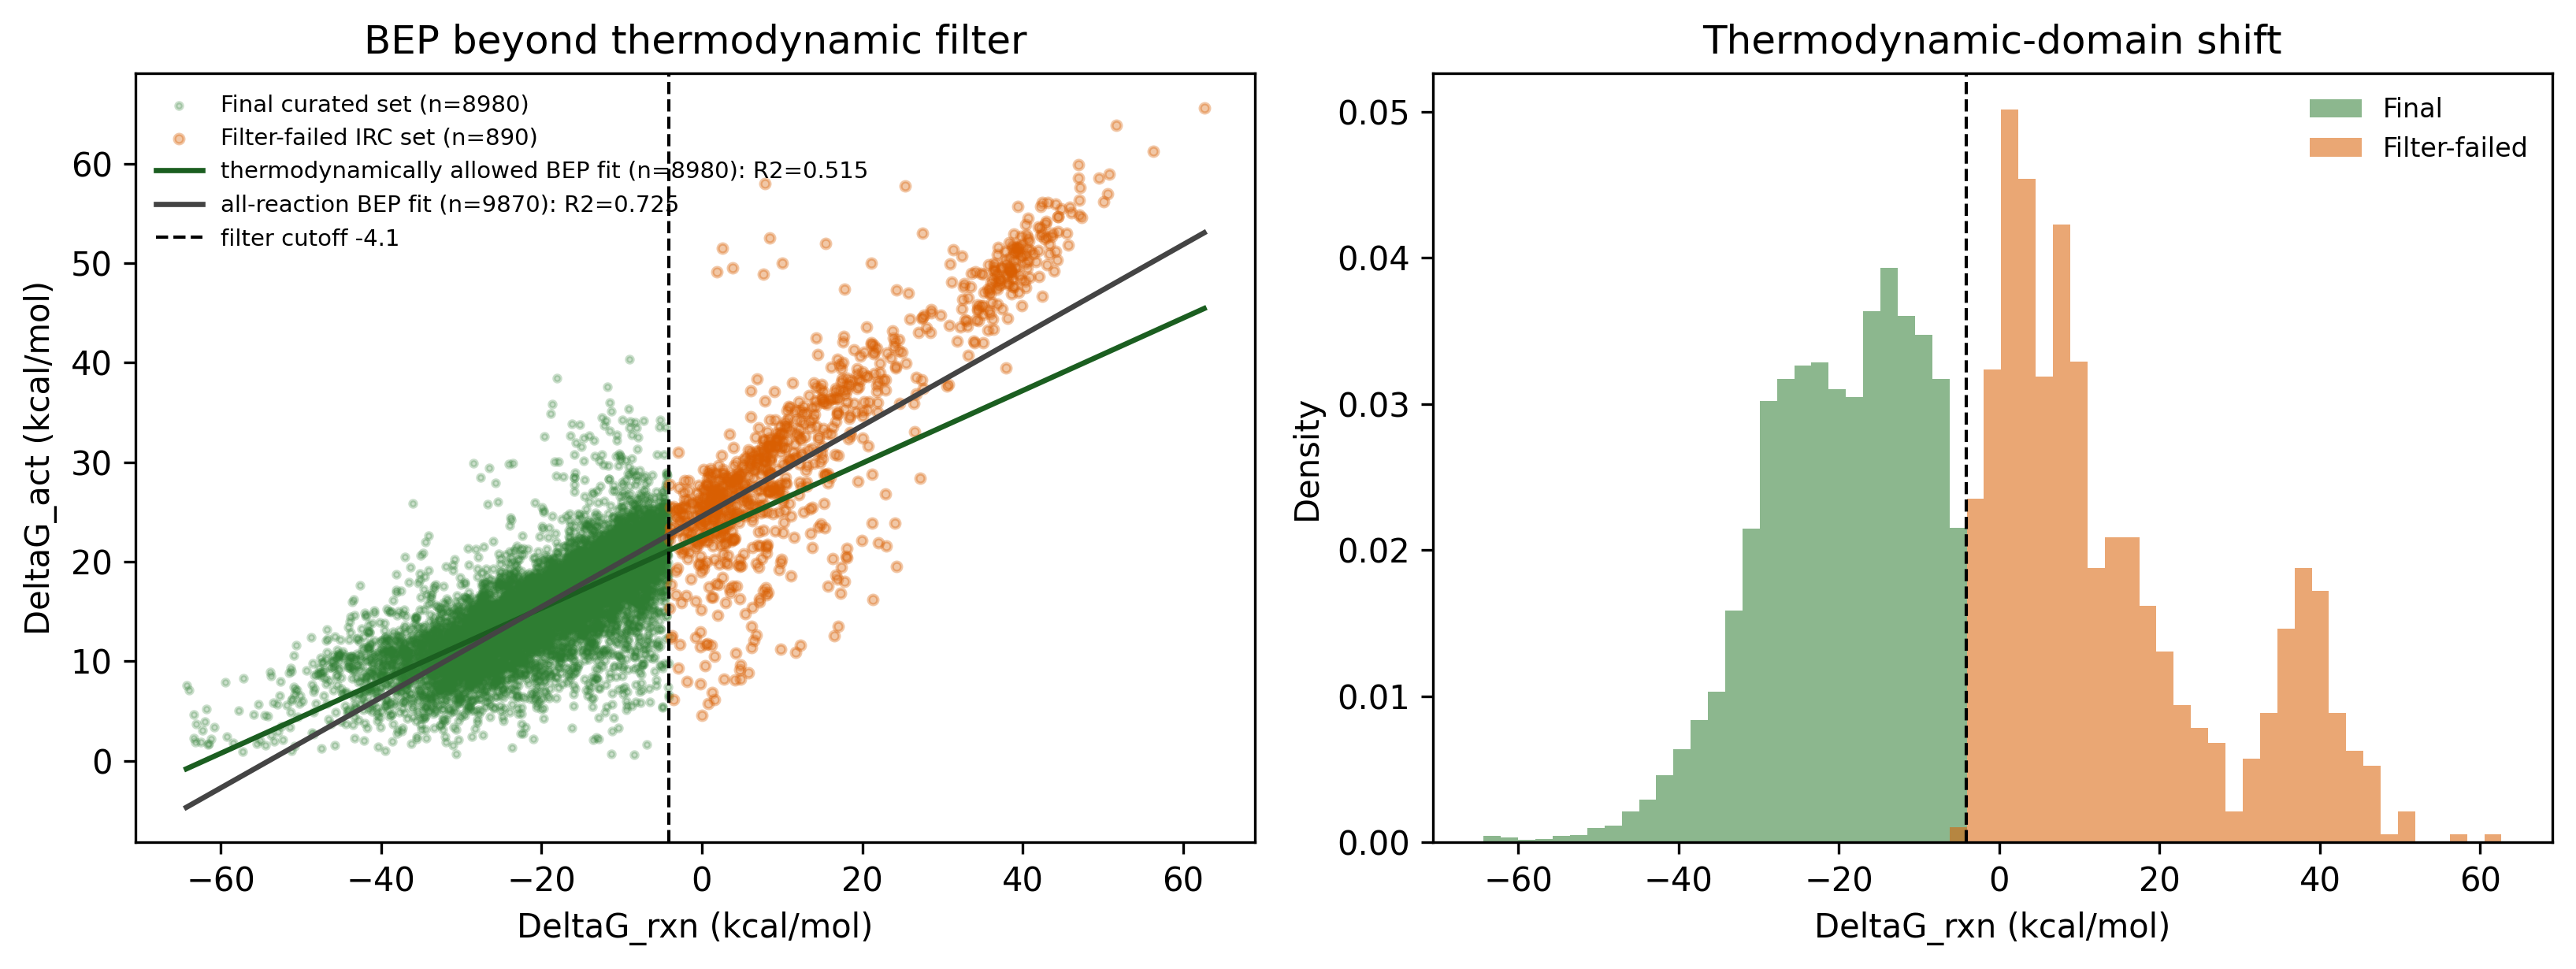

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), dpi=300)

ax = axes[0]
ax.scatter(
    final_df["deltaG(kcal/mol)"], final_df["deltaGa(kcal/mol)"],
    s=4, alpha=0.25, c="#2e7d32", label=f"Final curated set (n={len(final_df)})",
)
ax.scatter(
    extended_df["deltaG(kcal/mol)"], extended_df["deltaGa(kcal/mol)"],
    s=8, alpha=0.35, c="#d95f02", label=f"Filter-failed IRC set (n={len(extended_df)})",
)

for data, color, label, x_col, y_col in [
    (
        final_df,
        "#1b5e20",
        f"thermodynamically allowed BEP fit (n={len(final_df)})",
        FINAL_REACTION_ENERGY_COLUMN,
        FINAL_BARRIER_COLUMN,
    ),
    (
        combined_df,
        "#444444",
        f"all-reaction BEP fit (n={len(combined_df)})",
        FINAL_REACTION_ENERGY_COLUMN,
        FINAL_BARRIER_COLUMN,
    ),
]:
    x = data[x_col].to_numpy().reshape(-1, 1)
    y = data[y_col].to_numpy()
    model = LinearRegression().fit(x, y)
    xs = np.linspace(combined_df["deltaG(kcal/mol)"].min(), combined_df["deltaG(kcal/mol)"].max(), 200)
    ax.plot(xs, model.predict(xs.reshape(-1, 1)), color=color, lw=1.6, label=f"{label}: R2={r2_score(y, model.predict(x)):.3f}")

ax.axvline(THERMO_CUTOFF, color="black", ls="--", lw=1, label=f"filter cutoff {THERMO_CUTOFF}")
ax.set_xlabel("DeltaG_rxn (kcal/mol)")
ax.set_ylabel("DeltaG_act (kcal/mol)")
ax.set_title("BEP beyond thermodynamic filter")
ax.legend(frameon=False, fontsize=7, loc="upper left")

ax = axes[1]
bins = np.linspace(combined_df["deltaG(kcal/mol)"].min(), combined_df["deltaG(kcal/mol)"].max(), 60)
ax.hist(final_df["deltaG(kcal/mol)"], bins=bins, density=True, alpha=0.55, color="#2e7d32", label="Final")
ax.hist(extended_df["deltaG(kcal/mol)"], bins=bins, density=True, alpha=0.55, color="#d95f02", label="Filter-failed")
ax.axvline(THERMO_CUTOFF, color="black", ls="--", lw=1)
ax.set_xlabel("DeltaG_rxn (kcal/mol)")
ax.set_ylabel("Density")
ax.set_title("Thermodynamic-domain shift")
ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "Revision_ThermoFilter_BEP_Extension.png", bbox_inches="tight")
plt.show()


## 4. Similar-Size BEP Comparison

To compare BEP correlation at a similar sample size, the next figure overlays a reproducible random 900-point sample from the 8980-row final set with the full 946-row filter-failed set. The two sloped reference lines correspond to the BEP fit for the thermodynamically allowed final set and the BEP fit for all reactions combined.


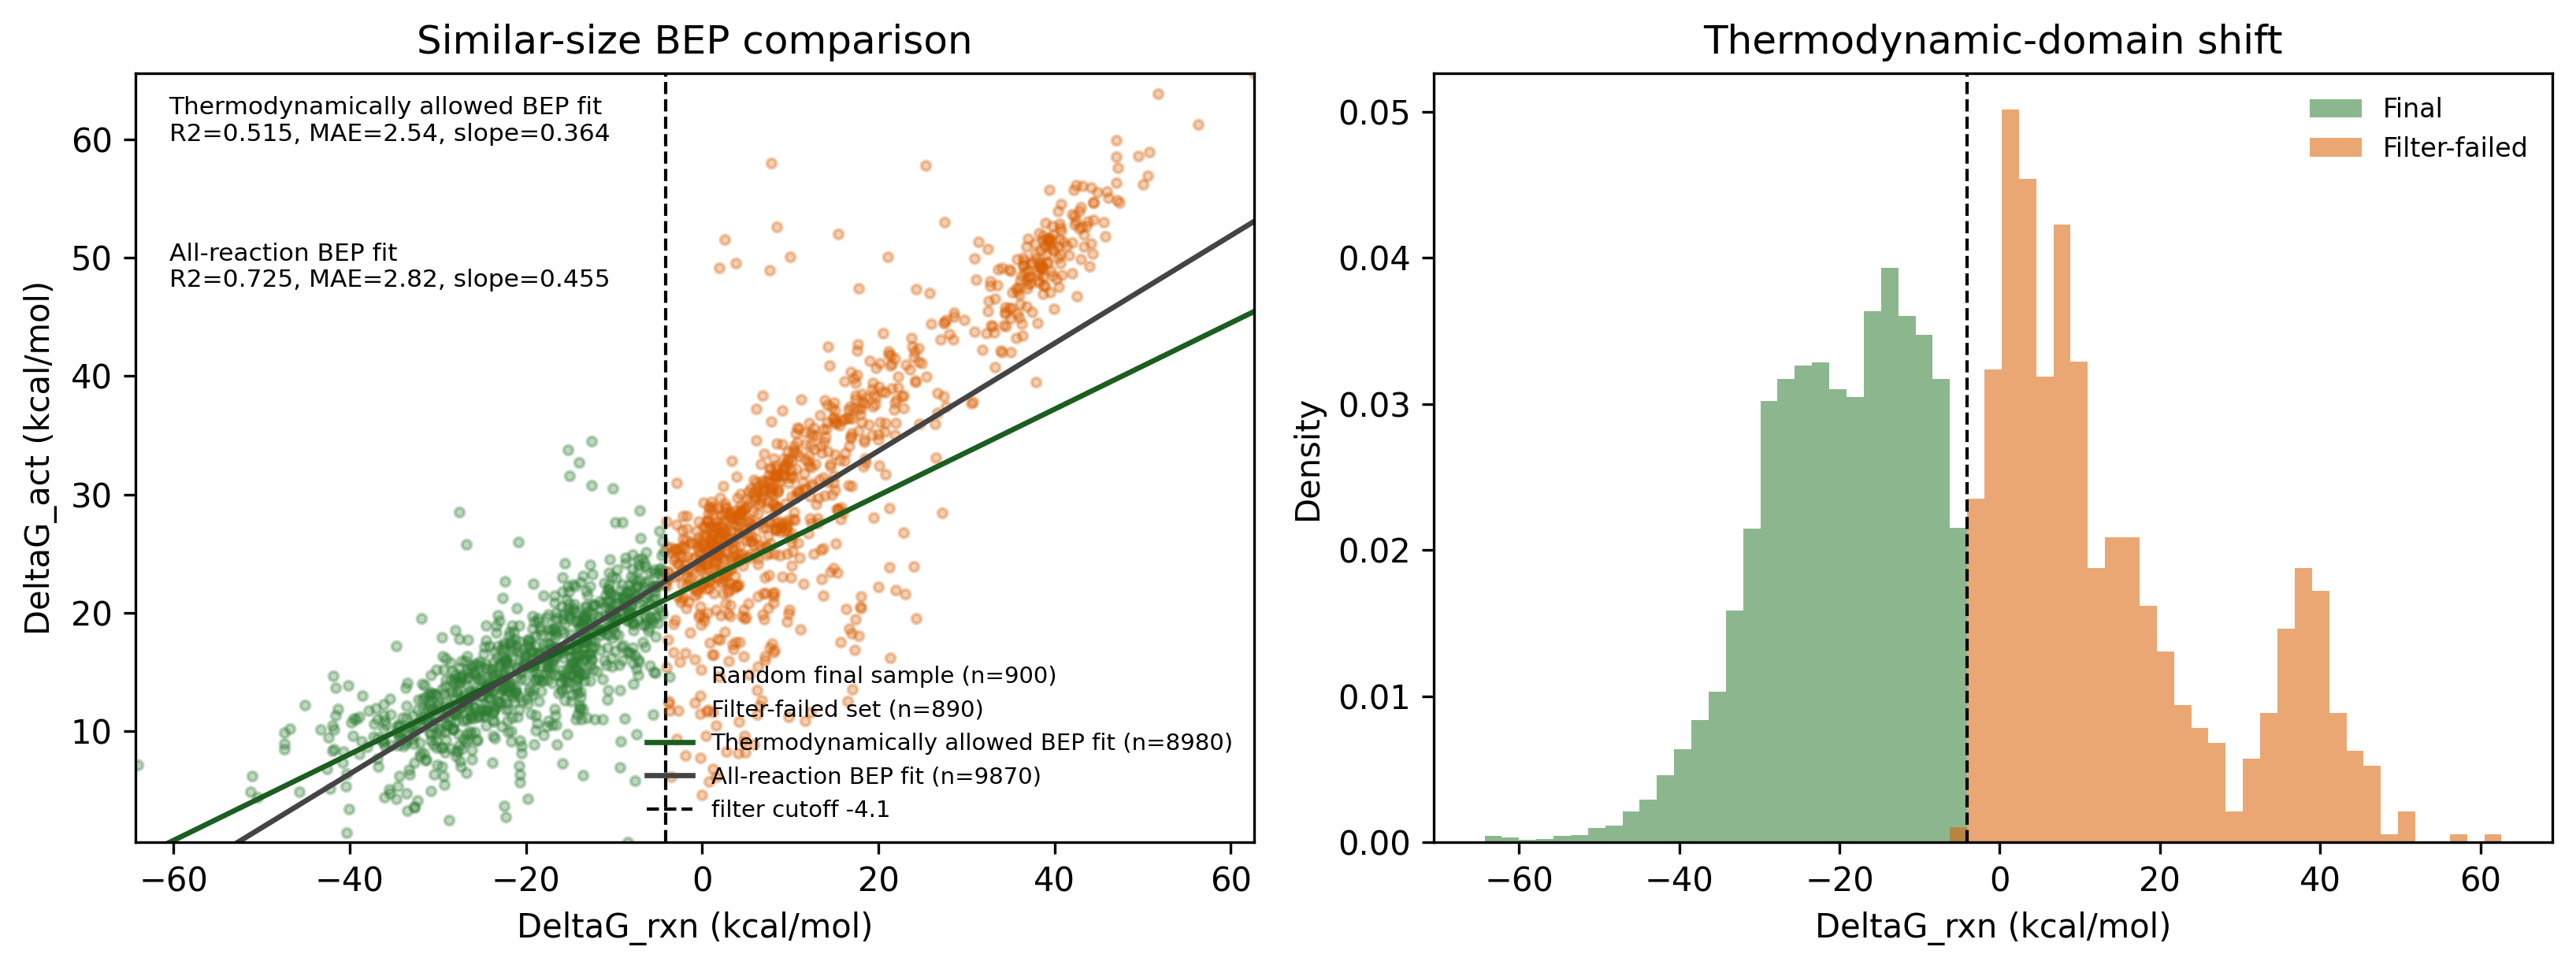

In [20]:
sampled_final_df = final_df.sample(n=min(SAMPLED_FINAL_N, len(final_df)), random_state=RANDOM_STATE).copy()

size_matched_bep_summary = pd.DataFrame([
    fit_bep(f"final_random_{len(sampled_final_df)}", sampled_final_df, FINAL_REACTION_ENERGY_COLUMN, FINAL_BARRIER_COLUMN),
    fit_bep(f"filter_failed_all_{len(extended_df)}", extended_df, EXTENDED_REACTION_ENERGY_COLUMN, EXTENDED_BARRIER_COLUMN),
])
size_matched_bep_summary.to_csv(OUTPUT_DIR / "bep_size_matched_summary.csv", index=False)

final_fit_stats = fit_bep(
    f"thermodynamically_allowed_{len(final_df)}",
    final_df,
    FINAL_REACTION_ENERGY_COLUMN,
    FINAL_BARRIER_COLUMN,
)
all_reaction_fit_stats = fit_bep(
    f"all_reactions_{len(combined_df)}",
    combined_df,
    FINAL_REACTION_ENERGY_COLUMN,
    FINAL_BARRIER_COLUMN,
)

x_limits = (
    combined_df["deltaG(kcal/mol)"].min(),
    combined_df["deltaG(kcal/mol)"].max(),
)
y_limits = (
    min(final_df["deltaGa(kcal/mol)"].min(), extended_df["deltaGa(kcal/mol)"].min()),
    max(final_df["deltaGa(kcal/mol)"].max(), extended_df["deltaGa(kcal/mol)"].max()),
)
xs = np.linspace(x_limits[0], x_limits[1], 200)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), dpi=300)
ax = axes[0]
scatter_specs = [
    (
        sampled_final_df,
        "#2e7d32",
        f"Random final sample (n={len(sampled_final_df)})",
    ),
    (
        extended_df,
        "#d95f02",
        f"Filter-failed set (n={len(extended_df)})",
    ),
]

for data, color, label in scatter_specs:
    ax.scatter(
        data["deltaG(kcal/mol)"],
        data["deltaGa(kcal/mol)"],
        s=8,
        alpha=0.30,
        color=color,
        label=label,
    )

for data, color, label, x_col, y_col, stats, text_xy in [
    (
        final_df,
        "#1b5e20",
        "Thermodynamically allowed BEP fit",
        FINAL_REACTION_ENERGY_COLUMN,
        FINAL_BARRIER_COLUMN,
        final_fit_stats,
        (0.03, 0.97),
    ),
    (
        combined_df,
        "#444444",
        "All-reaction BEP fit",
        FINAL_REACTION_ENERGY_COLUMN,
        FINAL_BARRIER_COLUMN,
        all_reaction_fit_stats,
        (0.03, 0.78),
    ),
]:
    x = data[x_col].to_numpy().reshape(-1, 1)
    y = data[y_col].to_numpy()
    model = LinearRegression().fit(x, y)
    ax.plot(
        xs,
        model.predict(xs.reshape(-1, 1)),
        color=color,
        lw=1.6,
        label=f"{label} (n={len(data)})",
    )
    ax.text(
        text_xy[0],
        text_xy[1],
        f"{label}\nR2={stats['R2']:.3f}, MAE={stats['MAE']:.2f}, slope={stats['slope']:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=7.5,
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.88, "edgecolor": "none"},
    )

ax.axvline(THERMO_CUTOFF, color="black", ls="--", lw=1, label=f"filter cutoff {THERMO_CUTOFF}")
ax.set_xlim(x_limits)
ax.set_ylim(y_limits)
ax.set_xlabel("DeltaG_rxn (kcal/mol)")
ax.set_ylabel("DeltaG_act (kcal/mol)")
ax.set_title("Similar-size BEP comparison")
ax.legend(frameon=False, fontsize=7, loc="lower right")

size_matched_bep_summary
ax = axes[1]
bins = np.linspace(combined_df["deltaG(kcal/mol)"].min(), combined_df["deltaG(kcal/mol)"].max(), 60)
ax.hist(final_df["deltaG(kcal/mol)"], bins=bins, density=True, alpha=0.55, color="#2e7d32", label="Final")
ax.hist(extended_df["deltaG(kcal/mol)"], bins=bins, density=True, alpha=0.55, color="#d95f02", label="Filter-failed")
ax.axvline(THERMO_CUTOFF, color="black", ls="--", lw=1)
ax.set_xlabel("DeltaG_rxn (kcal/mol)")
ax.set_ylabel("Density")
ax.set_title("Thermodynamic-domain shift")
ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "Revision_ThermoFilter_BEP_SizeMatched_Compare.png", bbox_inches="tight")
plt.show()

## 5. Descriptor Coverage

The original descriptor maps are reused without recomputing DFT descriptors. This is only valid if every filter-failed reaction has both its LB-B descriptor and its chloride/radical descriptor available.


In [14]:
DUPLICATE_CL_IDS = [
    624, 625, 626, 627, 628, 629, 630, 631, 632, 633, 634, 635, 636,
    637, 638, 639, 640, 642, 644, 645, 652, 653, 654, 655, 656, 657,
    658, 659, 660, 661, 662, 663, 664, 665, 666, 667, 668, 669, 670,
    671, 672, 673, 674, 675, 676, 677, 678, 679, 680, 681, 682, 683,
    684, 685, 686, 687, 688, 689, 690, 691, 692, 693, 694, 695, 696,
    697, 698, 699, 700, 701, 702, 703, 704, 705, 706, 707, 708, 709,
    710, 711, 713, 714, 716, 717, 718, 719, 720, 721, 722,
]

with open(DESCRIPTOR_DIR / "BNdes_new2.pkl", "rb") as handle:
    bn_map = pickle.load(handle)
with open(DESCRIPTOR_DIR / "Cldes_new2.pkl", "rb") as handle:
    cl_map = pickle.load(handle)


def descriptor_keys(df):
    keys = df[["B_Index", "N_Index", "Cl_Index", "Cl_Atomid"]].copy()
    keys["bn_key"] = [f"B_{int(b):05d}_Nu_{int(n):05d}" for b, n in zip(keys["B_Index"], keys["N_Index"])]
    keys["cl_key"] = [
        f"Cl_{int(cl):05d}_Claid_{int(atom):05d}" if int(cl) in DUPLICATE_CL_IDS else f"Cl_{int(cl):05d}"
        for cl, atom in zip(keys["Cl_Index"], keys["Cl_Atomid"])
    ]
    return keys

coverage = descriptor_keys(extended_df)
coverage["bn_descriptor_available"] = coverage["bn_key"].isin(bn_map)
coverage["cl_descriptor_available"] = coverage["cl_key"].isin(cl_map)
coverage["all_descriptors_available"] = coverage["bn_descriptor_available"] & coverage["cl_descriptor_available"]

coverage_summary = coverage[["bn_descriptor_available", "cl_descriptor_available", "all_descriptors_available"]].sum().to_frame("covered")
coverage_summary["total"] = len(coverage)
coverage_summary["fraction"] = coverage_summary["covered"] / coverage_summary["total"]
coverage_summary


,covered,total,fraction
bn_descriptor_available,890,890,1.0
cl_descriptor_available,890,890,1.0
all_descriptors_available,890,890,1.0


## 6. Reactant Coverage Of The Filter-Failed Set

This section checks whether the 1076 thermodynamically unfavorable reactions are broad or concentrated in a small number of reactants.




In [15]:
def lb_type_from_index(n_index):
    n_index = int(n_index)
    if 69 <= n_index < 144:
        return "Phosphine"
    if 144 <= n_index < 234:
        return "NHC"
    if (0 <= n_index < 69) or (234 <= n_index < 388):
        return "Amine/Aryl N"
    return "Other"


def cl_type_from_smiles(smiles):
    n_cl = str(smiles).count("Cl")
    if n_cl >= 4:
        return "CCl4"
    if n_cl == 3:
        return "CCl3"
    if n_cl == 2:
        return "CCl2"
    return "CCl"

coverage_df = extended_df.copy()
coverage_df["LB_type"] = coverage_df["N_Index"].map(lb_type_from_index)
coverage_df["Cl_type_simple"] = coverage_df["Cl_smiles"].map(cl_type_from_smiles)

final_components = {
    "B_Index": set(final_df["B_Index"].astype(int)),
    "N_Index": set(final_df["N_Index"].astype(int)),
    "Cl_Index": set(final_df["Cl_Index"].astype(int)),
}
ext_components = {
    "B_Index": set(coverage_df["B_Index"].astype(int)),
    "N_Index": set(coverage_df["N_Index"].astype(int)),
    "Cl_Index": set(coverage_df["Cl_Index"].astype(int)),
}

component_summary = []
for axis in ["B_Index", "N_Index", "Cl_Index"]:
    component_summary.append({
        "axis": axis,
        "extended_unique": len(ext_components[axis]),
        "final_unique": len(final_components[axis]),
        "extended_in_final": len(ext_components[axis] & final_components[axis]),
        "extended_not_in_final": len(ext_components[axis] - final_components[axis]),
        "fraction_of_final_component_space": len(ext_components[axis] & final_components[axis]) / len(final_components[axis]),
    })
component_summary = pd.DataFrame(component_summary)
component_summary


,axis,extended_unique,final_unique,extended_in_final,extended_not_in_final,fraction_of_final_component_space
0,B_Index,54,55,54,0,0.981818
1,N_Index,120,384,120,0,0.312500
2,Cl_Index,113,178,112,1,0.629213


In [16]:
coverage_tables = {
    "LB_type": coverage_df["LB_type"].value_counts().rename_axis("LB_type").reset_index(name="count"),
    "Cl_type_simple": coverage_df["Cl_type_simple"].value_counts().rename_axis("Cl_type_simple").reset_index(name="count"),
    "Top_B_Index": coverage_df["B_Index"].value_counts().head(20).rename_axis("B_Index").reset_index(name="count"),
    "Top_N_Index": coverage_df["N_Index"].value_counts().head(20).rename_axis("N_Index").reset_index(name="count"),
    "Top_Cl_Index": coverage_df["Cl_Index"].value_counts().head(20).rename_axis("Cl_Index").reset_index(name="count"),
}

for name, table in coverage_tables.items():
    print(f"\n{name}")
    display(table)



LB_type


,LB_type,count
0,Amine/Aryl N,470
1,NHC,245
2,Phosphine,175



Cl_type_simple


,Cl_type_simple,count
0,CCl2,470
1,CCl,363
2,CCl4,30
3,CCl3,27



Top_B_Index


,B_Index,count
0,423,191
1,388,54
2,389,42
3,409,39
4,404,38
5,401,27
6,403,26
7,393,23
8,390,21
9,400,21



Top_N_Index


,N_Index,count
0,160,121
1,143,73
2,306,57
3,377,54
4,333,49
5,141,45
6,302,34
7,292,23
8,195,19
9,291,19



Top_Cl_Index


,Cl_Index,count
0,483,205
1,490,66
2,492,50
3,488,39
4,480,35
5,485,35
6,479,30
7,484,26
8,462,20
9,486,19


## 7. First-Stage LB-B Complexation Filter Check

The extended set intentionally fails the second thermodynamic criterion, `DeltaG_rxn < -4.1 kcal/mol`. Here we check whether these reactions also contain LB-B pairs that fail the first complexation criterion, `DeltaG_comb < -4.1 kcal/mol`, using `Data/csvs/reactants_B_N_full.csv`.

This distinction matters for the response: if the first filter is still satisfied, the extended set isolates the effect of the reaction-free-energy filter rather than mixing in unstable LB-B complexes.


In [17]:
bn_full = pd.read_csv(CSV_DIR / "reactants_B_N_full.csv")
bn_selected = pd.read_csv(CSV_DIR / "reactants_B_N.csv")
if USE_QHARM:
    bn_full["deltaG_comb(kcal)"] = bn_full[BN_COMPLEXATION_COLUMN]
    bn_selected["deltaG_comb(kcal)"] = bn_selected[BN_COMPLEXATION_COLUMN]
for table in [bn_full, bn_selected, extended_df]:
    for col in ["B_Index", "N_Index"]:
        if col in table.columns:
            table[col] = table[col].astype(int)

# The selected table is the descriptor/database-relevant LB-B complex table and is unique by B/N pair.
selected_complex_check = extended_df.merge(
    bn_selected[["B_Index", "N_Index", "B_smiles", "N_smiles", "N_Atomid", "deltaG_comb(kcal)", "deltaE_comb(kcal)", "Error_reason"]],
    on=["B_Index", "N_Index"],
    how="left",
)
selected_complex_check["selected_passes_LB_B_filter"] = selected_complex_check["deltaG_comb(kcal)"] < -4.1
selected_complex_check["selected_fails_LB_B_filter"] = selected_complex_check["deltaG_comb(kcal)"] >= -4.1

# The full table can contain multiple candidate rows per B/N pair, so aggregate it cautiously.
full_pair_agg = bn_full.groupby(["B_Index", "N_Index"]).agg(
    full_candidate_count=("deltaG_comb(kcal)", "size"),
    full_nonmissing_count=("deltaG_comb(kcal)", lambda s: s.notna().sum()),
    full_min_deltaG_comb=("deltaG_comb(kcal)", "min"),
    full_max_deltaG_comb=("deltaG_comb(kcal)", "max"),
    full_any_fail=("deltaG_comb(kcal)", lambda s: bool((s >= -4.1).any())),
    full_all_fail=("deltaG_comb(kcal)", lambda s: bool(s.notna().all() and (s >= -4.1).all())),
    full_any_pass=("deltaG_comb(kcal)", lambda s: bool((s < -4.1).any())),
).reset_index()

extended_pairs = extended_df[["B_Index", "N_Index"]].drop_duplicates()
full_pair_check = extended_pairs.merge(full_pair_agg, on=["B_Index", "N_Index"], how="left")

complexation_summary = pd.DataFrame([
    {
        "level": "extended rows vs selected reactants_B_N.csv",
        "n": len(selected_complex_check),
        "missing_deltaG_comb": int(selected_complex_check["deltaG_comb(kcal)"].isna().sum()),
        "fails_deltaG_comb_ge_minus_4p1": int(selected_complex_check["selected_fails_LB_B_filter"].sum()),
        "passes_deltaG_comb_lt_minus_4p1": int(selected_complex_check["selected_passes_LB_B_filter"].sum()),
        "min_deltaG_comb": selected_complex_check["deltaG_comb(kcal)"].min(),
        "max_deltaG_comb": selected_complex_check["deltaG_comb(kcal)"].max(),
    },
    {
        "level": "unique B/N pairs vs full reactants_B_N_full.csv",
        "n": len(full_pair_check),
        "missing_deltaG_comb": int(full_pair_check["full_candidate_count"].isna().sum()),
        "fails_deltaG_comb_ge_minus_4p1": int(full_pair_check["full_any_fail"].sum()),
        "passes_deltaG_comb_lt_minus_4p1": int(full_pair_check["full_any_pass"].sum()),
        "min_deltaG_comb": full_pair_check["full_min_deltaG_comb"].min(),
        "max_deltaG_comb": full_pair_check["full_max_deltaG_comb"].max(),
    },
])


complexation_summary


,level,n,missing_deltaG_comb,fails_deltaG_comb_ge_minus_4p1,passes_deltaG_comb_lt_minus_4p1,min_deltaG_comb,max_deltaG_comb
0,extended rows vs selected reactants_B_N.csv,890,0,0,890,-95.260242,-10.176022
1,unique B/N pairs vs full reactants_B_N_full.csv,535,0,0,535,-95.260242,-10.176022


In [18]:
near_cutoff_rows = selected_complex_check.sort_values("deltaG_comb(kcal)", ascending=False).head(20)
near_cutoff_counts = pd.DataFrame({
    "threshold_deltaG_comb_greater_than": [-4.5, -5.0, -6.0, -8.0, -10.0],
    "row_count": [int((selected_complex_check["deltaG_comb(kcal)"] > cutoff).sum()) for cutoff in [-4.5, -5.0, -6.0, -8.0, -10.0]],
})
print(selected_complex_check["deltaG_comb(kcal)"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))
display(near_cutoff_counts)
display(near_cutoff_rows[["B_Index", "N_Index", "Cl_Index", "deltaG(kcal/mol)", "deltaGa(kcal/mol)", "deltaG_comb(kcal)"]])


count    890.000000
mean     -54.273036
std       19.282619
min      -95.260242
1%       -85.981915
5%       -81.871617
25%      -68.845933
50%      -56.375208
75%      -42.518555
95%      -18.935649
99%      -13.483341
max      -10.176022
Name: deltaG_comb(kcal), dtype: float64


,threshold_deltaG_comb_greater_than,row_count
0,-4.5,0
1,-5.0,0
2,-6.0,0
3,-8.0,0
4,-10.0,0


,B_Index,N_Index,Cl_Index,deltaG(kcal/mol),deltaGa(kcal/mol),deltaG_comb(kcal)
229,400,114,492,-0.246041,24.031850,-10.176022
813,436,122,492,4.226501,24.375039,-11.804656
812,436,122,477,-0.337392,23.907977,-11.804656
230,400,121,492,-1.797696,20.361793,-12.480206
823,437,141,481,-2.299109,26.964637,-13.353396
824,437,141,483,1.759840,28.839052,-13.353396
825,437,141,492,2.608266,29.235446,-13.353396
598,423,143,485,5.416306,27.810472,-13.483341
599,423,143,486,11.412620,31.045872,-13.483341
601,423,143,492,12.585359,34.961182,-13.483341


Interpretation for the response:

- None of the retained filter-failed reactions uses an LB-B pair with `DeltaG_comb >= -4.1 kcal/mol` in the selected `reactants_B_N.csv` table.
- The same conclusion holds at the unique B/N-pair level against `reactants_B_N_full.csv`: no matching B/N pair has a full-table candidate above the `-4.1 kcal/mol` complexation cutoff.
- Therefore, the extended set isolates the second thermodynamic filter (`DeltaG_rxn`) rather than mixing in reactions from unstable LB-B complexes.


## Notes For Manuscript/Response Drafting

Expected interpretation:

- The filtered extended set, after excluding `N_Index == 5`, provides a direct stress test for the thermodynamic reaction-free-energy filter. CSV outputs are limited to `bep_summary.csv` and `bep_size_matched_summary.csv` in `Ignored/revision_thermo_filter_outputs/`.
- Adding the filter-failed rows preserves the global BEP trend, so the BEP relationship is not simply an artifact of the `DeltaG_rxn < -4.1 kcal/mol` cutoff.
- Restricting the extended-fit line to `deltaG_qharm(kcal/mol) > -4.1 kcal/mol` isolates the thermodynamically unfavorable region explicitly in the full BEP figure.
- The 900-vs-946 comparison helps show that the weaker filter-failed correlation is not just a consequence of using far fewer points than the full 8980-row final set.
- Descriptor coverage is sufficient for the retained filter-failed rows because these reactions use LB-B and C-Cl components already present in the released reactant/product descriptor maps.
